# Day 4.6 — Comparative Evaluation
Three systems, one artifact, one hidden answer key — scored twice, against two reviewers. The
winner is not the same both times, and the single reviewer is allowed to win.

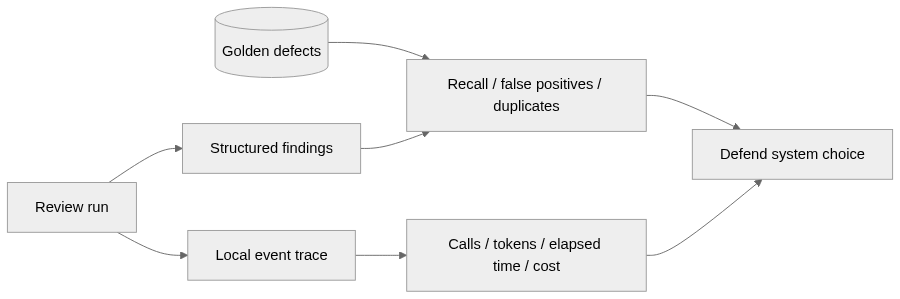

*D15 — findings and event trace from a run, scored against the golden defects, produce the decision*

### Step 1 — Assemble the two remaining systems

Nothing new: the checker from 4.3, the fan-out from 4.4, the supervisor from 4.5. Note the trace
entry for the deterministic step — an explicit zero, so no free step borrows a model's numbers.

In [ ]:
NO_MODEL_CALL = {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0,
                 "note": "no model call - deterministic code"}

def run_checks_plus_reviewer(source, model, max_findings=20, merge_by="location"):
    """System 2: prove what a parser can prove, then spend ONE model call on judgement."""
    start = perf_counter()
    checks = deterministic_checks(source)                          # free, deterministic, 0 tokens
    findings, usage = call_reviewer(source, "general", model)      # the only model call
    report = merge_findings([{"status": "ok", "findings": checks},
                             {"status": "ok", "findings": findings}], merge_by, max_findings=max_findings)
    return ReviewRun(system="checks_plus_reviewer", findings=report.findings, model_calls=1,
                     prompt_tokens=usage["prompt_tokens"], completion_tokens=usage["completion_tokens"],
                     elapsed_ms=(perf_counter() - start) * 1000, raw_findings=report.received,
                     merged_duplicates=report.merged_duplicates, dropped_over_cap=report.dropped_over_cap,
                     trace=[{"step": "deterministic_checks", "count": len(checks), "usage": NO_MODEL_CALL},
                            {"step": "general_reviewer", "count": len(findings), "usage": usage},
                            {"step": "supervisor", "count": report.kept, "merged": report.merged_duplicates,
                             "dropped_over_cap": report.dropped_over_cap, "merge_key": report.merge_key}])

def run_specialist_team(source, model, parallel=True, max_findings=20, merge_by="location"):
    """System 3: fan out to three narrow reviewers, then fan in at the supervisor."""
    start = perf_counter()
    results = fan_out(source, model, parallel=parallel)
    checks = deterministic_checks(source)
    branches = [{"status": "ok", "findings": checks}]
    branches += [{"status": "ok", "findings": findings} for _role, findings, _usage in results]
    report = merge_findings(branches, merge_by, max_findings=max_findings)
    usages = [usage for _role, _findings, usage in results]
    trace = [{"step": "deterministic_checks", "count": len(checks), "usage": NO_MODEL_CALL}]
    trace += [{"step": f"{role}_specialist", "count": len(findings), "usage": usage}
              for role, findings, usage in results]
    trace.append({"step": "supervisor", "count": report.kept, "received": report.received,
                  "merged": report.merged_duplicates, "dropped_over_cap": report.dropped_over_cap,
                  "merge_key": report.merge_key, "execution": "parallel" if parallel else "sequential"})
    return ReviewRun(system="specialist_team", findings=report.findings, model_calls=len(results),
                     prompt_tokens=sum(u["prompt_tokens"] for u in usages),
                     completion_tokens=sum(u["completion_tokens"] for u in usages),
                     elapsed_ms=(perf_counter() - start) * 1000, raw_findings=report.received,
                     merged_duplicates=report.merged_duplicates, dropped_over_cap=report.dropped_over_cap,
                     trace=trace)

smoke = run_specialist_team(SOURCE, reviewer_blind)
print("Systems ready. Smoke test:", smoke.system, "->", len(smoke.findings), "findings from",
      smoke.model_calls, "calls,", smoke.raw_findings, "raw,", smoke.merged_duplicates, "merged")

### Step 2 — One row of numbers per run

`evaluate` is `score` plus the telemetry the run measured. Cost is an estimate at a stated
catalogue price, labelled as one.

In [ ]:
PRICE_PER_MILLION_TOKENS = 0.15        # illustrative catalogue price, so you can redo the sums

def evaluate(run, price_per_million_tokens=PRICE_PER_MILLION_TOKENS):
    """Turn a ReviewRun into the row of numbers we compare architectures with."""
    row = score(run.findings)
    row.update(system=run.system, merged_duplicates=run.merged_duplicates,
               dropped_over_cap=run.dropped_over_cap, raw_findings=run.raw_findings,
               model_calls=run.model_calls, tokens=run.total_tokens,
               elapsed_ms=round(run.elapsed_ms, 1),
               estimated_cost_usd=round(run.total_tokens / 1_000_000 * price_per_million_tokens, 6))
    return row

COLUMNS = ["system", "found", "recall", "false_positives", "duplicates", "merged_duplicates",
           "model_calls", "tokens", "estimated_cost_usd"]

def score_all_systems(scenario):
    """Run the three architectures with the SAME reviewer and return one row each."""
    model = make_mock_model(scenario)
    return [evaluate(run_single_reviewer(SOURCE, model)),
            evaluate(run_checks_plus_reviewer(SOURCE, model)),
            evaluate(run_specialist_team(SOURCE, model))]

def print_table(scenario, rows):
    print("Scenario:", scenario)
    text = lambda row, col: ("%.6f" % row[col]) if col == "estimated_cost_usd" else str(row[col])
    widths = [max([len(col)] + [len(text(row, col)) for row in rows]) for col in COLUMNS]
    print(" | ".join(col.ljust(w) for col, w in zip(COLUMNS, widths)))
    print("-+-".join("-" * w for w in widths))
    for row in rows:
        print(" | ".join(text(row, col).ljust(w) for col, w in zip(COLUMNS, widths)))

rows_a = score_all_systems("blind_spots")
print_table("blind_spots", rows_a)
print("\nWhat each system missed:")
for row in rows_a:
    print(f"   {row['system']:<22} {row['missed'] or 'nothing'}")

### Try it yourself

Swap in the reviewer that is already strong — same architectures, same artifact. Write down which
system will win, and what "win" should even mean here.

In [ ]:
# --- Worked solution ---------------------------------------------------------------
rows_b = score_all_systems("strong_generalist")
print_table("strong_generalist", rows_b)

best = max(row["found"] for row in rows_b)
reaching = [row for row in rows_b if row["found"] == best]
cheapest = min(reaching, key=lambda row: (row["model_calls"], row["tokens"]))
print("\nMost defects any system found  :", best, "/ 9")
print("Systems that reached it        :", [row["system"] for row in reaching])
print("Smallest system that reached it:", cheapest["system"],
      f"({cheapest['model_calls']} call(s), {cheapest['tokens']} tokens, ${cheapest['estimated_cost_usd']:.6f})")
print('\n"Win" is not "found the most". It is "met the quality bar with the least".')
print("Here the team found nothing the single reviewer had not already found, and charged 3x for it.")

### Step 3 — Both scenarios side by side

Same architecture code, same artifact, opposite verdict. Only the reviewer's capability changed.

In [ ]:
print(f"{'scenario':<20}{'system':<24}{'found':>6}{'calls':>7}{'tokens':>8}{'cost $':>10}")
print("-" * 75)
for scenario, rows in (("blind_spots", rows_a), ("strong_generalist", rows_b)):
    for row in rows:
        print(f"{scenario:<20}{row['system']:<24}{row['found']:>6}{row['model_calls']:>7}"
              f"{row['tokens']:>8}{row['estimated_cost_usd']:>10.6f}")
    print()
for scenario, rows in (("blind_spots", rows_a), ("strong_generalist", rows_b)):
    single_row, team_row = rows[0], rows[2]
    print(f"{scenario:<20} team found {team_row['found'] - single_row['found']:+d} defect(s) for "
          f"{team_row['tokens'] - single_row['tokens']:+d} tokens and "
          f"{team_row['model_calls'] - single_row['model_calls']:+d} calls")

### Step 4 — When a multi-agent team is NOT worth it

Measured evidence instead of an opinion: these five lines are the deliverable of Day 4.

In [ ]:
reasons = [
    ("One reviewer already meets the bar",
     f"strong_generalist: single {rows_b[0]['found']}/9 vs team {rows_b[2]['found']}/9 -> "
     f"0 defects gained for {rows_b[2]['model_calls']}x the calls."),
    ("The extra recall costs more than it is worth",
     "Compare cost per extra defect against the cost of that defect escaping to production."),
    ("The sub-tasks are not genuinely independent",
     "If a branch needs another branch's output, the fan-out becomes a fragile pipeline."),
    ("The failure is a capability gap, not an attention gap",
     "DEF-COR-02 is missed by the generalist AND by the correctness specialist: a narrower "
     "prompt cannot supply knowledge the reviewer never had."),
    ("Debugging burden grows with branches",
     "4 branches plus a merge rule = 5 places a wrong report can come from, instead of 1."),
]
for index, (headline, evidence) in enumerate(reasons, 1):
    print(f"{index}. {headline}\n   evidence: {evidence}")

### Step 5 — A captured table for when the live call fails

A comparison captured earlier from the scripted reviewer, so a write-up always has a table even
if the provider is down. It records the classroom result, not evidence about any real model.

In [ ]:
CAPTURED_COMPARISON = {
    "note": "Captured offline from the scripted reviewer - no model was called.",
    "provider": "scripted reviewer (mock model)",
    "scenarios": {
        "blind_spots": [
            {"system": "single_reviewer",      "found": 5, "model_calls": 1, "tokens": 609},
            {"system": "checks_plus_reviewer", "found": 6, "model_calls": 1, "tokens": 609},
            {"system": "specialist_team",      "found": 9, "model_calls": 3, "tokens": 1448},
        ],
        "strong_generalist": [
            {"system": "single_reviewer",      "found": 8, "model_calls": 1, "tokens": 789},
            {"system": "checks_plus_reviewer", "found": 8, "model_calls": 1, "tokens": 789},
            {"system": "specialist_team",      "found": 8, "model_calls": 3, "tokens": 1393},
        ],
    },
}

print("Note     :", CAPTURED_COMPARISON["note"])
print("Provider :", CAPTURED_COMPARISON["provider"])
print("Status   :", "you ran live, so cite YOUR tables and use this only where a call failed"
      if LIVE else "no key, so this file and your tables agree by construction\n")
for scenario, rows in CAPTURED_COMPARISON["scenarios"].items():
    print(scenario)
    for row in rows:
        print(f"   {row['system']:<24} found {row['found']}/9 | calls {row['model_calls']} | tokens {row['tokens']}")

### Required live observation

With a key, run 4.2's live reviewer once and compare it with the scripted baseline: the findings
differ in wording, line choice and count, but arrive through the same schema and are scored by the
same `evaluate`. Record its real `usage` next to the mock numbers. The two *scenarios* stay
scripted on purpose — a real model cannot be given chosen blind spots. If the provider is down,
use the captured table and say so.

### Checkpoint

**1. In the `strong_generalist` scenario the specialist team found 8 defects — as many as any other system. Why is that not a win?**

<details><summary>Show answer</summary>

It found nothing the single reviewer had not, for 3 calls instead of 1, plus duplicates to merge and more places for a bug to hide. The question is never "which found the most" but "which is the smallest system that meets the bar".

</details>

**2. Both scenarios run exactly the same architecture code. So what changed the conclusion?**

<details><summary>Show answer</summary>

The reviewer's capability. "Multi-agent is better" means "decomposition compensated for *this* reviewer on *this* task", and must be re-measured when either changes.

</details>

### Recap

- **Limitation seen:** one comparison table can make a team look unconditionally better than one reviewer.
- **Layer added:** the same measurement repeated against a second reviewer, plus a captured table.
- **Evidence:** 5/9 → 9/9 in one world and 8/9 → 8/9 at 3x the cost in the other, from identical code.